In [1]:
import pandas as pd

learner_profile = pd.read_csv("../outputs/learner_profile.csv")

learner_profile.head()

,UserID,UserName,Age,Gender,Email,total_courses,enrollment_frequency,avg_spending,total_spending,diversity_score,avg_course_rating,preferred_category,preferred_level,learning_depth_index,preferred_teacher,teacher_diversity
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com,1,1,394.260000,394.26,1,1.350000,Cybersecurity,Intermediate,0.0,TC00031,1
1,U00002,angela22,29,Female,hallrandy@hotmail.com,1,1,0.000000,0.00,1,2.880000,Programming,Beginner,0.0,TC00009,1
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,11,11,55.816364,613.98,7,2.889091,Marketing,Advanced,0.8,TC00040,2
3,U00004,fthornton,23,Female,christensencatherine@outlook.com,13,13,75.542308,982.05,8,3.451538,Digital Marketing,Intermediate,0.6,TC00040,2
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com,2,2,173.355000,346.71,2,2.055000,Programming,Advanced,0.5,TC00015,2


### Select Features for clustering

In [2]:
features = learner_profile[
    [
        'total_courses',
        'enrollment_frequency',
        'avg_spending',
        'total_spending',
        'diversity_score',
        'avg_course_rating',
        'learning_depth_index',
        'teacher_diversity'
    ]
]

In [3]:
features

,total_courses,enrollment_frequency,avg_spending,total_spending,diversity_score,avg_course_rating,learning_depth_index,teacher_diversity
0,1,1,394.260000,394.26,1,1.350000,0.0,1
1,1,1,0.000000,0.00,1,2.880000,0.0,1
2,11,11,55.816364,613.98,7,2.889091,0.8,2
3,13,13,75.542308,982.05,8,3.451538,0.6,2
4,2,2,173.355000,346.71,2,2.055000,0.5,2
...,...,...,...,...,...,...,...,...
2995,1,1,0.000000,0.00,1,4.140000,0.0,1
2996,1,1,0.000000,0.00,1,1.810000,1.0,1
2997,1,1,37.890000,37.89,1,1.300000,1.0,1
2998,1,1,37.890000,37.89,1,1.300000,1.0,1


### Handle Scaling 

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [5]:
scaled_features

array([[-0.53622296, -0.53622296,  2.43865773, ..., -1.87732837,
        -0.85012995, -0.76395647],
       [-0.53622296, -0.53622296, -0.71456607, ..., -0.2668106 ,
        -0.85012995, -0.76395647],
       [ 1.76187544,  1.76187544, -0.26815638, ..., -0.25724128,
         0.42431577,  0.58340944],
       ...,
       [-0.53622296, -0.53622296, -0.41152836, ..., -1.92995967,
         0.7429272 , -0.76395647],
       [-0.53622296, -0.53622296, -0.41152836, ..., -1.92995967,
         0.7429272 , -0.76395647],
       [-0.53622296, -0.53622296,  2.43865773, ..., -1.87732837,
        -0.85012995, -0.76395647]], shape=(3000, 8))

### Find Optimal Number of Clusters (Elbow Method)

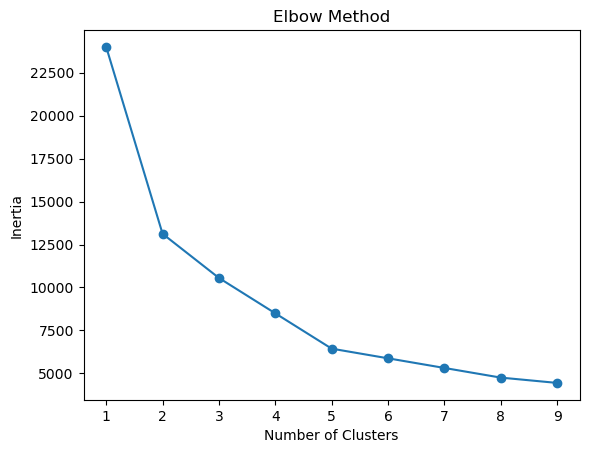

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### Silhouette Score (Validation)

##### Higher score = better clustering

In [7]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.5392729231567326
K=3, Silhouette Score=0.343832324067708
K=4, Silhouette Score=0.32403135682437717
K=5, Silhouette Score=0.3699865651328075
K=6, Silhouette Score=0.37053210184151436


### Apply Final K-Means

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
learner_profile['cluster'] = kmeans.fit_predict(scaled_features)

In [9]:
kmeans

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


### Analyze Clusters

In [16]:
#Calculate mean only for numeric columns
cluster_summary = learner_profile.groupby('cluster').mean(numeric_only=True)
print(cluster_summary)

               Age  total_courses  enrollment_frequency  avg_spending  \
cluster                                                                 
0        24.750507       2.864097              2.864097     79.854045   
1        25.037001       1.223466              1.223466     90.717909   
2        24.933775      13.410596             13.410596     93.449027   

         total_spending  diversity_score  avg_course_rating  \
cluster                                                       
0            234.477546         2.681542           3.084558   
1            111.525609         1.193281           3.149422   
2           1250.888389         8.739514           3.114381   

         learning_depth_index  teacher_diversity  
cluster                                           
0                    1.081981           2.738337  
1                    0.320716           1.190360  
2                    0.902371           2.000000  


In [15]:
# If you want to see both numeric means and non-numeric summaries
numeric_summary = learner_profile.groupby('cluster').mean(numeric_only=True)
print("Numeric columns summary:")
print(numeric_summary)

Numeric columns summary:
               Age  total_courses  enrollment_frequency  avg_spending  \
cluster                                                                 
0        24.750507       2.864097              2.864097     79.854045   
1        25.037001       1.223466              1.223466     90.717909   
2        24.933775      13.410596             13.410596     93.449027   

         total_spending  diversity_score  avg_course_rating  \
cluster                                                       
0            234.477546         2.681542           3.084558   
1            111.525609         1.193281           3.149422   
2           1250.888389         8.739514           3.114381   

         learning_depth_index  teacher_diversity  
cluster                                           
0                    1.081981           2.738337  
1                    0.320716           1.190360  
2                    0.902371           2.000000  


In [14]:
# Get non-numeric summary (most frequent values)
non_numeric_cols = learner_profile.select_dtypes(include=['object', 'category']).columns
if len(non_numeric_cols) > 0:
    categorical_summary = learner_profile.groupby('cluster')[non_numeric_cols].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'N/A')
    print("\nCategorical columns summary (most frequent values):")
    print(categorical_summary)


Categorical columns summary (most frequent values):
         UserID      UserName  Gender                    Email  \
cluster                                                          
0        U00017       aaron63  Female         aadams@gmail.com   
1        U00001  aaronfrazier  Female     aaguilar@hotmail.com   
2        U00003      acamacho  Female  aaronfigueroa@gmail.com   

              preferred_category preferred_level preferred_teacher  
cluster                                                             
0                       Business        Advanced           TC00008  
1        Artificial Intelligence        Beginner           TC00028  
2        Artificial Intelligence        Advanced           TC00040  


### Label Segments

##### Cluster 0 - Casual Learners (low engagement, low spending)
##### Cluster 1 - Explorers (high diversity, moderate activity)
##### Cluster 2 - Career-Focused (high spending, advanced learning)

### Visualization

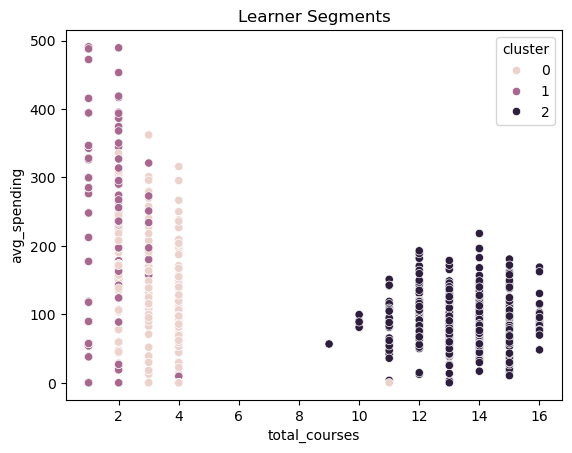

In [17]:
import seaborn as sns

sns.scatterplot(
    x=features['total_courses'],
    y=features['avg_spending'],
    hue=learner_profile['cluster']
)
plt.title("Learner Segments")
plt.show()

### Save Output

In [ ]:
learner_profile.to_csv(
"C:/Users/Harpreet/OneDrive/Desktop/EduPro_Project/outputs/clustered_learners.csv",
index=False
)